In [7]:
import random
import matplotlib.pyplot as plt
courses = [
 ("AI","DosenA"), ("ML","DosenB"), ("DB","DosenC"),
 ("CN","DosenD"), ("SE","DosenE"), ("OS","DosenF"),
 ("IR","DosenA"), ("NLP","DosenB"), ("CV","DosenC"),
 ("IOT","DosenD"), ("HCI","DosenE"), ("CyberSec","DosenF"),
 ("BigData","DosenA"), ("DL","DosenB"), ("NoSQL","DosenC"),
 ("Cloud","DosenD"), ("UX","DosenE"), ("SecEng","DosenF"),
 ("Agile","DosenA"), ("RL","DosenB"), ("ETL","DosenC"),
 ("DevOps","DosenD"), ("GameDev","DosenE"), ("Blockchain","DosenF")
]

rooms = ["R1","R2","R3","R4"]

timeslots = [
 "Senin-08","Senin-10","Senin-13",
 "Selasa-08","Selasa-10","Selasa-13",
 "Rabu-08","Rabu-10","Rabu-13",
 "Kamis-08","Kamis-10","Kamis-13"
]


In [8]:
def create_individual():
    return [(random.choice(rooms), random.choice(timeslots)) for _ in courses]

def fitness(ind):
    konflik = 0

    for i in range(len(ind)):
        for j in range(i+1, len(ind)):

            r1, t1 = ind[i]
            r2, t2 = ind[j]

            d1 = courses[i][1]
            d2 = courses[j][1]

            if r1 == r2 and t1 == t2:
                konflik += 1

            if d1 == d2 and t1 == t2:
                konflik += 1

            if d1 == d2 and t1.split("-")[0] == t2.split("-")[0]:
                konflik += 1

    return 100 - konflik

In [9]:
def init_pop(n=60):
    return [create_individual() for _ in range(n)]

def selection(pop):
    a, b = random.sample(pop, 2)
    return a if fitness(a) > fitness(b) else b

def crossover(p1, p2):
    point = random.randint(1, len(p1)-1)
    return p1[:point] + p2[point:]

def mutate(ind):
    if random.random() < 0.2:
        i = random.randint(0, len(ind)-1)
        ind[i] = (random.choice(rooms), random.choice(timeslots))
    return ind

In [10]:
pop = init_pop()

max_fit = []
avg_fit = []

for gen in range(100):
    fits = [fitness(i) for i in pop]

    max_fit.append(max(fits))
    avg_fit.append(sum(fits)/len(fits))

    print(f"Gen {gen+1} | Max: {max(fits)} | Avg: {sum(fits)/len(fits):.2f}")

    new_pop = []
    for _ in range(len(pop)):
        p1 = selection(pop)
        p2 = selection(pop)
        child = crossover(p1, p2)
        child = mutate(child)
        new_pop.append(child)

    pop = new_pop

Gen 1 | Max: 93 | Avg: 82.18
Gen 2 | Max: 94 | Avg: 84.20
Gen 3 | Max: 93 | Avg: 85.37
Gen 4 | Max: 93 | Avg: 86.50
Gen 5 | Max: 93 | Avg: 87.30
Gen 6 | Max: 95 | Avg: 87.18
Gen 7 | Max: 94 | Avg: 88.17
Gen 8 | Max: 93 | Avg: 88.17
Gen 9 | Max: 94 | Avg: 89.05
Gen 10 | Max: 94 | Avg: 88.97
Gen 11 | Max: 96 | Avg: 89.47
Gen 12 | Max: 95 | Avg: 89.72
Gen 13 | Max: 95 | Avg: 90.15
Gen 14 | Max: 95 | Avg: 90.58
Gen 15 | Max: 95 | Avg: 90.83
Gen 16 | Max: 95 | Avg: 90.58
Gen 17 | Max: 94 | Avg: 90.68
Gen 18 | Max: 97 | Avg: 91.28
Gen 19 | Max: 97 | Avg: 91.68
Gen 20 | Max: 98 | Avg: 92.45
Gen 21 | Max: 97 | Avg: 92.65
Gen 22 | Max: 97 | Avg: 93.42
Gen 23 | Max: 97 | Avg: 93.78
Gen 24 | Max: 97 | Avg: 94.22
Gen 25 | Max: 97 | Avg: 94.35
Gen 26 | Max: 98 | Avg: 94.90
Gen 27 | Max: 98 | Avg: 95.50
Gen 28 | Max: 98 | Avg: 95.33
Gen 29 | Max: 98 | Avg: 95.47
Gen 30 | Max: 99 | Avg: 95.93
Gen 31 | Max: 99 | Avg: 95.82
Gen 32 | Max: 99 | Avg: 96.28
Gen 33 | Max: 99 | Avg: 96.63
Gen 34 | Max: 99 | 

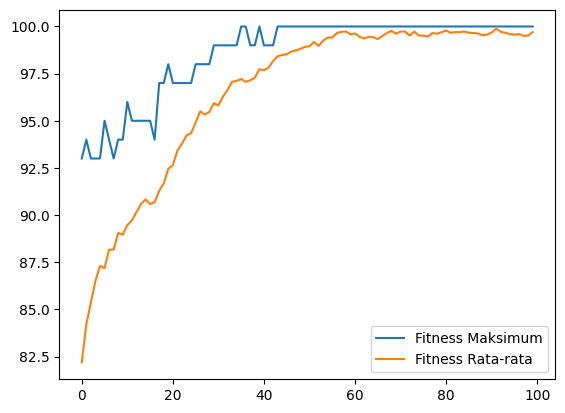

In [11]:
plt.plot(max_fit, label="Fitness Maksimum")
plt.plot(avg_fit, label="Fitness Rata-rata")
plt.legend()
plt.show()

In [12]:
best = max(pop, key=fitness)

for i, gene in enumerate(best):
    print(courses[i][0], "|", gene[0], "|", gene[1], "|", courses[i][1])

AI | R4 | Rabu-08 | DosenA
ML | R4 | Senin-08 | DosenB
DB | R4 | Kamis-08 | DosenC
CN | R2 | Selasa-10 | DosenD
SE | R4 | Senin-10 | DosenE
OS | R2 | Selasa-13 | DosenF
IR | R2 | Selasa-08 | DosenA
NLP | R1 | Kamis-13 | DosenB
CV | R3 | Rabu-13 | DosenC
IOT | R1 | Rabu-08 | DosenD
HCI | R2 | Rabu-13 | DosenE
CyberSec | R3 | Kamis-13 | DosenF
BigData | R3 | Senin-08 | DosenA
DL | R1 | Rabu-13 | DosenB
NoSQL | R4 | Selasa-10 | DosenC
Cloud | R2 | Senin-08 | DosenD
UX | R4 | Selasa-08 | DosenE
SecEng | R4 | Senin-13 | DosenF
Agile | R1 | Kamis-10 | DosenA
RL | R1 | Selasa-13 | DosenB
ETL | R2 | Senin-10 | DosenC
DevOps | R4 | Kamis-13 | DosenD
GameDev | R1 | Kamis-08 | DosenE
Blockchain | R3 | Rabu-10 | DosenF
